In [ ]:
# use gmos filter curve, detected spectral type, and magnitude with Spextra to get the simulated flux

In [17]:
from astropy.io import fits
from astropy.wcs import WCS

# import
oiii_hdu = fits.open("images/normalized_OIII.fits")
oiiic_hdu = fits.open("images/normalized_OIIIC.fits")
wcs_hdul = fits.open("images/SNR_OIII.fits")

# images
oiii_image = oiii_hdu[0].data
oiiic_image = oiii_hdu[0].data

# image headers
oiii_header = oiii_hdu[0].header
oiiic_header = oiiic_hdu[0].header

# create WCS
wcs = WCS(wcs_hdul["SCI"].header)

wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 86.9519162984652 -70.4145638364921 
CRPIX : 1567.851522483014 1069.07832988416 
CD1_1 CD1_2  : -1.1558431745326e-05 4.30113955981334e-05 
CD2_1 CD2_2  : -4.291815952434e-05 -1.1548898773803e-05 
NAXIS : 3164  2175

[0.03193856 0.03825495 0.02422652]


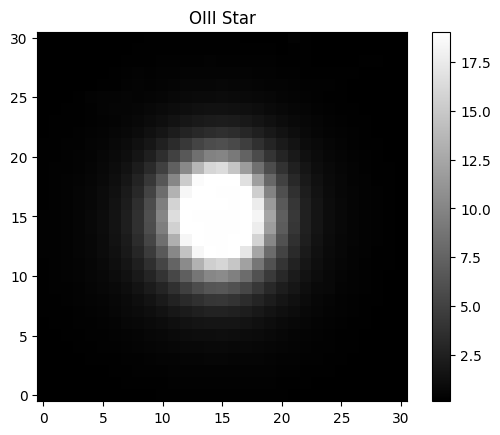

In [ ]:
# identify a star in the image first
import numpy as np
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from astropy.nddata import Cutout2D

# OIII stats
mean, median, std = sigma_clipped_stats(oiii_image)
print(np.array((mean, median, std)))

# create a list of detected sources
daofind = DAOStarFinder(fwhm=7.0, threshold=5*std, roundlo=-0.2, roundhi=0.2)
sources_oiii = daofind(oiii_image - median)

# get the brightest star for now
brightest = sources_oiii[np.argmax(sources_oiii["flux"])]

In [76]:
# # plot a specific star for now to check
# import matplotlib.pyplot as plt

# sources_oiii.sort("flux")
# sources_oiii.reverse()
# key_star = sources_oiii[1]


# size = 31
# x = key_star["x_centroid"]
# y = key_star["y_centroid"]
# cutout = (Cutout2D(oiii_image, (x, y), (size, size)).data)

# plt.imshow(cutout, origin="lower", cmap="gray", vmin=np.nanpercentile(cutout, 5), vmax=np.nanpercentile(cutout, 99.5))
# plt.colorbar()
# plt.title("OIII Star")
# plt.show()

# print(x, y)

In [77]:
star_index = 0

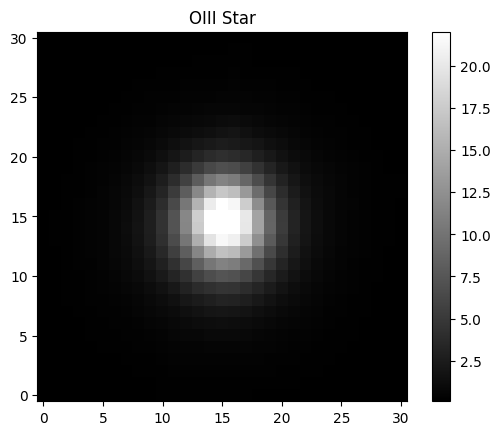

811.2054256040692 604.5209644019868
No match.


In [89]:
# plot a specific star for now to check
import matplotlib.pyplot as plt

sources_oiii.sort("flux")
sources_oiii.reverse()
key_star = sources_oiii[1]


size = 31
x = key_star["x_centroid"]
y = key_star["y_centroid"]
cutout = (Cutout2D(oiii_image, (x, y), (size, size)).data)

plt.imshow(cutout, origin="lower", cmap="gray", vmin=np.nanpercentile(cutout, 5), vmax=np.nanpercentile(cutout, 99.5))
plt.colorbar()
plt.title("OIII Star")
plt.show()

print(x, y)


# look up object in catalogue
from astroquery.simbad import Simbad
import astropy.units as u
import pandas as pd

coord = wcs.pixel_to_world(x, y)

# print(coord)

# print(coord.to_string("hmsdms"))
Simbad.add_votable_fields("sptype")
result = Simbad.query_region(coord, radius=2*u.arcsec)

if result is None:
    print("No match.")
    star_index += 1
else:
    df = result["MAIN_ID", "SP_TYPE"].to_pandas()
    display(df)